In [53]:
import warnings
warnings.filterwarnings('ignore')

import os, requests, time
from io import StringIO
from datetime import datetime
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import lightgbm as lgb
import vectorbt as vbt
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'grid.color': '#30363d', 'axes.edgecolor': '#30363d',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d'
})

TODAY       = datetime.today().strftime('%Y-%m-%d')
TRAIN_START = '2020-01-01'
TRAIN_END   = '2022-01-01'
TEST_END    = '2024-01-01'
OHLCV_START = '2019-06-01'
TARGET_PCT  = 0.12
SL_PCT      = 0.03
HOLD_DAYS   = 3
MKTCAP_MIN  = 500
TOP_N       = 3
REBAL_DAYS  = 3

FEATURE_COLS = [
    'atr_squeeze',     # 38% — ATR compressed vs its own 20-bar avg
    'bb_squeeze',      # 19% — Bollinger width compressed vs its own 20-bar avg
    'near_high',       #  9% — proximity to 10-bar high (near = better)
    'vol_momentum',    #  8% — volume × up-bar factor
    'momentum_2w',     #  7% — 2-bar price return
    'ema_dip',         #  6% — below EMA20 (oversold dip)
    'rsi_oversold',    #  3% — RSI < 60 zone
    'trend_26w',       #  3% — 6-month uptrend context
    'stoch_oversold',  #  3% — stoch_d < 40 oversold zone
    'obv_accel',       #  2% — OBV slope z-score
    'macd_strength',   #  2% — MACD histogram strength
]

print(f'✅ Setup complete | Today: {TODAY}')
print(f'📅 Train: {TRAIN_START}→{TRAIN_END} | Backtest: {TRAIN_END}→{TEST_END} | Validate: {TEST_END}→{TODAY}')
print(f'🤖 Model: LightGBM GBDT  |  Backtest: vectorbt  |  Features: pandas_ta')

✅ Setup complete | Today: 2026-03-21
📅 Train: 2020-01-01→2022-01-01 | Backtest: 2022-01-01→2024-01-01 | Validate: 2024-01-01→2026-03-21
🤖 Model: LightGBM GBDT  |  Backtest: vectorbt  |  Features: pandas_ta


In [54]:
def fetch_nse_symbols():
    url = 'https://nsearchives.nseindia.com/content/equities/EQUITY_L.csv'
    headers = {'User-Agent': 'Mozilla/5.0', 'Referer': 'https://www.nseindia.com'}
    try:
        s = requests.Session()
        s.get('https://www.nseindia.com', headers=headers, timeout=10)
        r = s.get(url, headers=headers, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        col = [c for c in df.columns if 'SYMBOL' in c.upper()][0]
        syms = df[col].dropna().str.strip().tolist()
        print(f'NSE live: {len(syms)} symbols')
        return syms
    except Exception as e:
        print(f'Live fetch failed ({e}) -> curated fallback')

nse_df = fetch_nse_symbols()
print(f'Total: {len(nse_df)} symbols')

NSE live: 2250 symbols
Total: 2250 symbols


In [55]:
def download_ohlcv(symbols, start='2019-01-01', end=TODAY,
                   interval='1d', suffix='.NS', batch=50):
    result, failed = {}, []
    tickers = [s + suffix for s in symbols]
    for i in tqdm(range(0, len(tickers), batch), desc='OHLCV'):
        grp = tickers[i:i+batch]
        try:
            raw = yf.download(
                grp, start=start, end=end, interval=interval,
                group_by='ticker', auto_adjust=True,
                progress=False, threads=True
            )
            for t in grp:
                sym = t.replace(suffix, '')
                try:
                    df = raw[t].copy() if len(grp) > 1 else raw.copy()
                    df.dropna(subset=['Close'], inplace=True)
                    if len(df) >= 52:
                        df.columns = [c.lower() for c in df.columns]
                        result[sym] = df
                    else:
                        failed.append(sym)
                except Exception:
                    failed.append(sym)
        except Exception as e:
            print(f'Batch error: {e}')
        time.sleep(0.3)
    print(f'Downloaded: {len(result)} | Skipped: {len(failed)}')
    return result

print('Downloading OHLCV (may take a few minutes)...')
ohlcv_data = download_ohlcv(nse_df, start=OHLCV_START)
print(f'Universe: {len(ohlcv_data)} stocks')

OHLCV:   0%|          | 0/45 [00:00<?, ?it/s]

Downloaded: 2214 | Skipped: 36
Universe: 2214 stocks


In [56]:
MCAP_THREADS = 50
SUFFIX       = '.NS'
MCAP_CACHE   = 'mcap_cache.csv'

def _fetch_one(sym, suffix=SUFFIX):
    try:
        mc = yf.Ticker(sym + suffix).fast_info.market_cap
        return sym, round(mc / 1e7, 2) if mc else None
    except Exception:
        return sym, None

def fetch_mcap(symbols, suffix=SUFFIX, cache_path=MCAP_CACHE, n_threads=MCAP_THREADS):
    if os.path.exists(cache_path):
        _df       = pd.read_csv(cache_path, index_col=0)
        mcap_dict = _df['mcap_cr'].to_dict()
        print(f'Loaded {len(mcap_dict)} cached entries from {cache_path}')
    else:
        mcap_dict = {}
    missing = [s for s in symbols if s not in mcap_dict]
    if not missing:
        print('All symbols already cached. Skipping fetch.')
        return mcap_dict
    print(f'Fetching mcap for {len(missing)} symbols ({n_threads} threads)...')
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=n_threads) as pool:
        futures = {pool.submit(_fetch_one, sym, suffix): sym for sym in missing}
        for future in tqdm(as_completed(futures), total=len(futures), desc='MCap fetch'):
            sym, mc = future.result()
            mcap_dict[sym] = mc
    print(f'Fetched in {time.time()-t0:.1f}s')
    pd.DataFrame.from_dict(mcap_dict, orient='index', columns=['mcap_cr']).to_csv(cache_path)
    print(f'Cache saved -> {cache_path}')
    return mcap_dict

mcap_cache = fetch_mcap(list(ohlcv_data.keys()))
before     = len(ohlcv_data)
ohlcv_data = {sym: df for sym, df in ohlcv_data.items()
              if mcap_cache.get(sym) is not None and mcap_cache[sym] >= 500}
after = len(ohlcv_data)
print(f'\nMarket cap filter : >= Rs {MKTCAP_MIN:,} Cr')
print(f'Before            : {before} symbols')
print(f'Removed           : {before - after}')
print(f'After             : {after} symbols')

mcap_series = pd.Series({s: mcap_cache[s] for s in ohlcv_data if mcap_cache.get(s)})
bins   = [0, 500, 2_000, 10_000, 50_000, 100_000, float('inf')]
labels = ['<500 Cr','500-2k','2k-10k','10k-50k','50k-1L Cr','>1L Cr']
dist   = pd.cut(mcap_series, bins=bins, labels=labels).value_counts().sort_index()
print('\n  MCap distribution:')
for band, count in dist.items():
    bar = chr(9608) * int(count / max(dist.values) * 30)
    print(f'  {band:12s}  {count:5d}  {bar}')

Loaded 2217 cached entries from mcap_cache.csv
All symbols already cached. Skipping fetch.

Market cap filter : >= Rs 500 Cr
Before            : 2214 symbols
Removed           : 1584
After             : 630 symbols

  MCap distribution:
  <500 Cr           0  
  500-2k          200  ██████████████████████████
  2k-10k          227  ██████████████████████████████
  10k-50k         132  █████████████████
  50k-1L Cr        30  ███
  >1L Cr           41  █████


📡 Downloading Nifty 50 for regime filter...

  Regime breakdown (2019-06-01 → 2026-03-21):
  🟢 BULLISH  : 50.4%  — training rows INCLUDED, trades ALLOWED
  🟡 CAUTION  : 28.0%  — training rows EXCLUDED, trades BLOCKED
  🔴 BEARISH  : 21.7%  — training rows EXCLUDED, trades BLOCKED


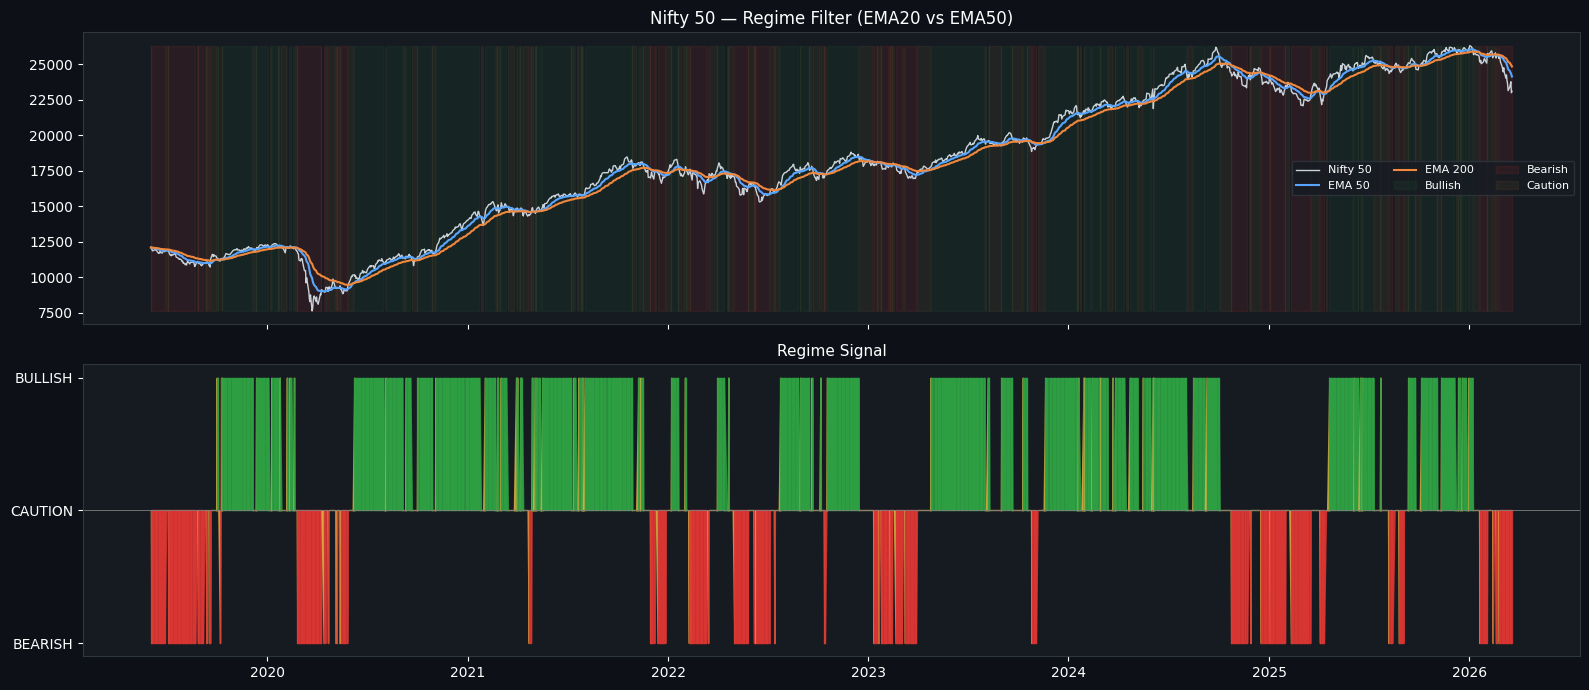


✅ Regime filter ready. Example: regime_on("2024-01-15") = True


In [57]:
print('📡 Downloading Nifty 50 for regime filter...')
nifty_raw  = yf.download('^NSEI', start=OHLCV_START, end=TODAY,
                          auto_adjust=True, progress=False)
nifty_close = nifty_raw['Close'].squeeze().rename('nifty').dropna()
nifty_close.index = pd.to_datetime(nifty_close.index)

# ── Regime indicators ──────────────────────────────────────────────
nifty_df            = pd.DataFrame({'close': nifty_close})
nifty_df['ema20']   = nifty_df['close'].ewm(span=20,  adjust=False).mean()
nifty_df['ema50']  = nifty_df['close'].ewm(span=50, adjust=False).mean()

# ── Classify each trading day ──────────────────────────────────────
bull = (nifty_df['close'] > nifty_df['ema20'])  & (nifty_df['ema20'] >= nifty_df['ema50'])
bear = (nifty_df['close'] < nifty_df['ema20'])  & (nifty_df['ema20'] < nifty_df['ema50'])
nifty_df['regime'] = np.select([bull, bear], ['BULLISH', 'BEARISH'], default='CAUTION')

# ── Boolean Series — forward-fillable lookup ───────────────────────
is_bullish = (nifty_df['regime'] == 'BULLISH') | (nifty_df['regime'] == 'CAUTION')

def regime_on(date_str: str) -> bool:
    """Return True if Nifty is in BULLISH regime on or before date_str."""
    try:
        val = is_bullish.loc[:pd.Timestamp(date_str)].iloc[-1]
        return bool(val)
    except Exception:
        return False

# ── Summary ────────────────────────────────────────────────────────
pct_b = (nifty_df['regime'] == 'BULLISH').mean() * 100
pct_c = (nifty_df['regime'] == 'CAUTION').mean() * 100
pct_r = (nifty_df['regime'] == 'BEARISH').mean() * 100
print(f'\n  Regime breakdown ({OHLCV_START} → {TODAY}):')
print(f'  🟢 BULLISH  : {pct_b:.1f}%  — training rows INCLUDED, trades ALLOWED')
print(f'  🟡 CAUTION  : {pct_c:.1f}%  — training rows EXCLUDED, trades BLOCKED')
print(f'  🔴 BEARISH  : {pct_r:.1f}%  — training rows EXCLUDED, trades BLOCKED')

# ── Regime chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.patch.set_facecolor('#0d1117')

axes[0].plot(nifty_df.index, nifty_df['close'],  color='#c9d1d9', lw=1,   label='Nifty 50')
axes[0].plot(nifty_df.index, nifty_df['ema20'],  color='#58a6ff', lw=1.5, label='EMA 50')
axes[0].plot(nifty_df.index, nifty_df['ema50'], color='#f0883e', lw=1.5, label='EMA 200')
axes[0].fill_between(nifty_df.index, nifty_df['close'].min(), nifty_df['close'].max(),
                     where=(nifty_df['regime']=='BULLISH'), alpha=0.07, color='#2ea043', label='Bullish')
axes[0].fill_between(nifty_df.index, nifty_df['close'].min(), nifty_df['close'].max(),
                     where=(nifty_df['regime']=='BEARISH'), alpha=0.10, color='#da3633', label='Bearish')
axes[0].fill_between(nifty_df.index, nifty_df['close'].min(), nifty_df['close'].max(),
                     where=(nifty_df['regime']=='CAUTION'), alpha=0.06, color='#e3b341', label='Caution')
axes[0].set_title('Nifty 50 — Regime Filter (EMA20 vs EMA50)', color='white', fontsize=12)
axes[0].legend(fontsize=8, ncol=3)

regime_num = nifty_df['regime'].map({'BULLISH': 1, 'CAUTION': 0, 'BEARISH': -1})
clr = np.where(regime_num==1, '#2ea043', np.where(regime_num==-1, '#da3633', '#e3b341'))
for i in range(len(regime_num)-1):
    axes[1].fill_between(nifty_df.index[i:i+2], regime_num.iloc[i:i+2], 0,
                         color=clr[i], alpha=0.8)
axes[1].axhline(0, color='gray', lw=0.6)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(['BEARISH', 'CAUTION', 'BULLISH'], color='white')
axes[1].set_title('Regime Signal', color='white', fontsize=11)

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#30363d')
plt.tight_layout()
plt.show()
print(f'\n✅ Regime filter ready. Example: regime_on("2024-01-15") = {regime_on("2024-01-15")}')

In [58]:
def compute_features(df):
    d   = df.copy()
    d.columns = [c.lower() for c in d.columns]
    c, h, l, o, v = d['close'], d['high'], d['low'], d['open'], d['volume']

    # ── 1. ATR SQUEEZE (38%) ─────────────────────────────────────────
    atr_abs          = ta.atr(h, l, c, length=14)
    d['atr_pct']     = atr_abs / c
    atr_baseline     = d['atr_pct'].rolling(20).mean().replace(0, np.nan)
    atr_ratio        = d['atr_pct'] / atr_baseline
    d['atr_squeeze'] = np.clip(2 * (1 - atr_ratio), 0, 1).fillna(0)
    d['atr_14']      = atr_abs

    # ── 2. BB SQUEEZE (19%) ──────────────────────────────────────────
    bb               = ta.bbands(c, length=20, std=2)
    bb_bw_col        = [col for col in bb.columns if col.startswith('BBB')][0]
    d['bb_width']    = bb[bb_bw_col] / 100
    bb_baseline      = d['bb_width'].rolling(20).mean().replace(0, np.nan)
    bb_ratio         = d['bb_width'] / bb_baseline
    d['bb_squeeze']  = np.clip(2 * (1 - bb_ratio), 0, 1).fillna(0)
    d['bb_squeeze_raw'] = (d['bb_width'] <= d['bb_width'].rolling(20).min() * 1.05).astype(int)

    # ── 3. NEAR HIGH (9%) ────────────────────────────────────────────
    d['resist_10w']    = h.rolling(10).max()
    d['pct_to_resist'] = (d['resist_10w'] - c) / c * 100
    d['near_high']     = np.clip(1 - d['pct_to_resist'] / 12, 0, 1).fillna(0)
    d['near_resistance'] = (d['pct_to_resist'] <= 3).astype(int)

    # ── 4. VOLUME MOMENTUM (8%) ──────────────────────────────────────
    d['vol_ma20']     = v.rolling(20).mean()
    d['vol_ratio']    = v / d['vol_ma20']
    up_bar            = (c > c.shift(1)).astype(float)
    d['vol_momentum'] = (np.clip((d['vol_ratio'] - 0.8) / 2.2, 0, 1) * (0.1 + 0.9 * up_bar)).fillna(0)
    d['vol_surge']    = ((d['vol_ratio'] >= 1.5) & (c > c.shift(1))).astype(int)

    # ── 5. 2-BAR MOMENTUM (7%) ───────────────────────────────────────
    d['ret_2w']      = c.pct_change(2) * 100
    d['momentum_2w'] = np.clip(d['ret_2w'] / 5, 0, 1).fillna(0)

    # ── 6. EMA DIP (6%) ──────────────────────────────────────────────
    d['ema_20']       = ta.ema(c, length=20)
    d['ema_50']       = ta.ema(c, length=50)
    ema_dist          = (c - d['ema_20']) / d['ema_20'] * 100
    d['ema_dist_pct'] = ema_dist
    d['ema_dip']      = np.clip(-ema_dist / 8, 0, 1).fillna(0)
    d['vol_price_confirm'] = ((d['vol_ratio'] >= 1.2) & (c > d['ema_20'])).astype(int)

    # ── 7. RSI OVERSOLD (3%) ─────────────────────────────────────────
    d['rsi_14']       = ta.rsi(c, length=14)
    d['rsi_oversold'] = np.clip((60 - d['rsi_14']) / 40, 0, 1).fillna(0)
    d['rsi_zone']     = pd.cut(d['rsi_14'], bins=[0,30,50,70,100], labels=[0,1,2,3]).astype(float)

    # ── 8. 26-BAR TREND (3%) ─────────────────────────────────────────
    d['ret_26w']   = c.pct_change(26) * 100
    d['trend_26w'] = np.clip(d['ret_26w'] / 40, 0, 1).fillna(0)

    # ── 9. STOCHASTIC OVERSOLD (3%) ──────────────────────────────────
    stoch              = ta.stoch(h, l, c, k=14, d=3, smooth_k=3)
    stoch_k_col        = [col for col in stoch.columns if col.startswith('STOCHk')][0]
    stoch_d_col        = [col for col in stoch.columns if col.startswith('STOCHd')][0]
    d['stoch_k']        = stoch[stoch_k_col]
    d['stoch_d']        = stoch[stoch_d_col]
    d['stoch_cross_up'] = ((d['stoch_k'] > d['stoch_d']) & (d['stoch_k'].shift(1) <= d['stoch_d'].shift(1))).astype(int)
    d['stoch_oversold'] = np.clip((40 - d['stoch_d']) / 35, 0, 1).fillna(0)

    # ── 10. OBV ACCELERATION (2%) ────────────────────────────────────
    d['obv']         = ta.obv(c, v)
    d['obv_rising']  = (d['obv'] > d['obv'].shift(4)).astype(int)
    obv_chg          = d['obv'].diff(10)
    obv_mean         = obv_chg.rolling(20).mean()
    obv_std          = obv_chg.rolling(20).std().replace(0, np.nan)
    obv_z            = ((obv_chg - obv_mean) / obv_std).clip(-3, 3).fillna(0)
    d['obv_slope_z'] = obv_z
    d['obv_accel']   = (obv_z + 3) / 6

    # ── 11. MACD STRENGTH (2%) ───────────────────────────────────────
    macd              = ta.macd(c, fast=12, slow=26, signal=9)
    macd_h_col        = [col for col in macd.columns if col.startswith('MACDh')][0]
    d['macd_hist']    = macd[macd_h_col]
    d['macd_cross_up'] = ((d['macd_hist'] > 0) & (d['macd_hist'].shift(1) <= 0)).astype(int)
    hist_std           = d['macd_hist'].rolling(20).std().replace(0, np.nan)
    hist_z             = (d['macd_hist'] / hist_std).clip(-3, 3).fillna(0)
    d['macd_strength'] = np.clip((hist_z + 1) / 2, 0, 1)

    # ── CONTEXT ONLY ─────────────────────────────────────────────────
    adx               = ta.adx(h, l, c, length=14)
    d['adx']          = adx['ADX_14']
    d['di_plus']      = adx['DMP_14']
    d['di_minus']     = adx['DMN_14']
    d['52w_high']          = h.rolling(52).max()
    d['pct_from_52w_high'] = (c - d['52w_high']) / d['52w_high'] * 100

    # Forward return target
    d['target_ret'] = c.shift(-HOLD_DAYS) / c - 1
    return d


print('Engineering features...')

def _feat_worker(tk):
    try:
        fd = compute_features(ohlcv_data[tk])
        fd['symbol'] = tk
        return tk, fd
    except Exception:
        return tk, None

results = Parallel(n_jobs=-1, backend='threading')(
    delayed(_feat_worker)(tk) for tk in tqdm(ohlcv_data, desc='Features')
)
feature_store = {tk: fd for tk, fd in results if fd is not None and len(fd) > 150}
print(f'Features ready for {len(feature_store)} symbols')
sample = list(feature_store.values())[0]
print(f'Sample shape: {sample.shape}')
sample[FEATURE_COLS + ['target_ret']].tail(3)

Engineering features...


Features:   0%|          | 0/630 [00:00<?, ?it/s]

Features ready for 593 symbols
Sample shape: (1684, 49)


,atr_squeeze,bb_squeeze,near_high,vol_momentum,momentum_2w,ema_dip,rsi_oversold,trend_26w,stoch_oversold,obv_accel,macd_strength,target_ret
Date,,,,,,,,,,,,
2026-03-18,0.0,0.0,0.163622,0.120956,0.623885,0.771605,0.674865,0.0,0.728509,0.380414,0.0,NaN
2026-03-19,0.0,0.0,0.000000,0.015099,0.000000,1.000000,0.788083,0.0,0.648591,0.377407,0.0,NaN
2026-03-20,0.0,0.0,0.000000,0.196291,0.000000,0.948954,0.740744,0.0,0.588450,0.454808,0.0,NaN


In [59]:
def build_panel(fstore: dict, start: str, end: str,
               regime_series: pd.Series = None):
    """
    Stack all stocks' features in [start, end) into a single matrix.
    If regime_series is provided, only rows where regime is True are kept.
    """
    Xs, ys, tks, dts = [], [], [], []
    regime_filtered_rows = 0
    total_rows = 0

    for tk, df in fstore.items():
        mask = (df.index >= start) & (df.index < end)
        sub  = df.loc[mask].dropna(subset=FEATURE_COLS + ['target_ret'])
        if len(sub) < 20:
            continue
        total_rows += len(sub)

        # ── Apply regime filter ───────────────────────────────────────
        if regime_series is not None:
            # Align regime series to sub's dates
            reg_aligned = regime_series.reindex(sub.index, method='ffill').fillna(False)
            sub = sub[reg_aligned.values]
            regime_filtered_rows += len(sub)

        if len(sub) < 10:
            continue

        Xs.append(sub[FEATURE_COLS].values)
        ys.append(sub['target_ret'].values)
        tks.extend([tk] * len(sub))
        dts.extend(sub.index.tolist())

    X = np.vstack(Xs).astype(np.float32)
    y = np.concatenate(ys).astype(np.float32)

    if regime_series is not None:
        pct_kept = regime_filtered_rows / total_rows * 100 if total_rows else 0
        print(f'   Regime filter: kept {regime_filtered_rows:,} / {total_rows:,} rows ({pct_kept:.1f}% — bullish only)')

    return X, y, np.array(tks), np.array(dts)


print('🏗️  Building training panel (BULLISH regime rows only)...')
X_train, y_train, tk_train, dt_train = build_panel(
    feature_store, TRAIN_START, TRAIN_END,
    regime_series=is_bullish          # ← regime gate applied here
)

clip_mask        = np.abs(y_train) < 0.30
X_train, y_train = X_train[clip_mask], y_train[clip_mask]

print(f'   X_train shape : {X_train.shape}')
print(f'   y range       : [{y_train.min():.3f}, {y_train.max():.3f}]  mean={y_train.mean():.4f}')

🏗️  Building training panel (BULLISH regime rows only)...
   Regime filter: kept 183,220 / 210,047 rows (87.2% — bullish only)
   X_train shape : (182696, 11)
   y range       : [-0.294, 0.300]  mean=0.0075


In [60]:
LGB_PARAMS = {
    'objective'        : 'regression',
    'metric'           : 'mae',
    'boosting_type'    : 'gbdt',
    'num_leaves'       : 31,
    'max_depth'        : 5,
    'learning_rate'    : 0.03,
    'n_estimators'     : 1000,
    'min_child_samples': 50,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'verbosity'        : -1,
    'n_jobs'           : -1,
    'random_state'     : 42
}

tscv = TimeSeriesSplit(n_splits=5)
cv_scores, best_iters = [], []

print('🔁 LightGBM — TimeSeriesSplit CV (5 folds, bullish-only training data)...')
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                     lgb.log_evaluation(period=-1)])
    preds    = m.predict(X_va)
    mae      = mean_absolute_error(y_va, preds)
    ic, pval = spearmanr(preds, y_va)
    best_iters.append(m.best_iteration_)
    cv_scores.append({'fold': fold, 'mae': mae, 'IC': ic, 'best_iter': m.best_iteration_})
    print(f'  Fold {fold}:  MAE={mae:.5f}  IC={ic:.4f}  best_iter={m.best_iteration_}')

cv_df         = pd.DataFrame(cv_scores)
optimal_iters = int(np.median(best_iters))
print(f'\n  Avg MAE : {cv_df["mae"].mean():.5f}')
print(f'  Avg IC  : {cv_df["IC"].mean():.4f}')
print(f'  Optimal n_estimators: {optimal_iters}')

print(f'\n🚀 Training final model ({X_train.shape[0]:,} rows, {optimal_iters} trees)...')
FINAL_PARAMS = {**LGB_PARAMS, 'n_estimators': optimal_iters}
lgbm_model   = lgb.LGBMRegressor(**FINAL_PARAMS)
lgbm_model.fit(X_train, y_train)
in_preds = lgbm_model.predict(X_train)
print(f'   In-sample MAE : {mean_absolute_error(y_train, in_preds):.5f}')
print(f'   In-sample R²  : {r2_score(y_train, in_preds):.4f}')
print(f'✅ LightGBM trained — {optimal_iters} trees, {len(FEATURE_COLS)} features')

🔁 LightGBM — TimeSeriesSplit CV (5 folds, bullish-only training data)...
  Fold 1:  MAE=0.03749  IC=0.0770  best_iter=140
  Fold 2:  MAE=0.03617  IC=0.0598  best_iter=46
  Fold 3:  MAE=0.04065  IC=0.0982  best_iter=185
  Fold 4:  MAE=0.03921  IC=0.1022  best_iter=315
  Fold 5:  MAE=0.03651  IC=0.0914  best_iter=235

  Avg MAE : 0.03801
  Avg IC  : 0.0857
  Optimal n_estimators: 185

🚀 Training final model (182,696 rows, 185 trees)...
   In-sample MAE : 0.03758
   In-sample R²  : 0.0403
✅ LightGBM trained — 185 trees, 11 features


In [61]:
# ── Rolling retrain config ────────────────────────────────────────
TRAIN_WINDOW_MONTHS = 24   # how many months of history to train on
RETRAIN_EVERY_MONTHS = 6   # how often to retrain (months)

def months_offset(date_str, n_months):
    """Return date_str shifted forward by n_months."""
    dt = pd.Timestamp(date_str)
    # Use pd.DateOffset for clean month arithmetic
    return (dt + pd.DateOffset(months=n_months)).strftime('%Y-%m-%d')

def retrain_model(feature_store, regime_series, train_start, train_end,
                  lgb_params, optimal_iters):
    """
    Train a fresh LightGBM on bullish-regime rows in [train_start, train_end].
    Returns (model, W_approx, scaler, X_train, y_train, importance_df).
    """
    X, y, _, _ = build_panel(feature_store, train_start, train_end,
                              regime_series=regime_series)
    clip = np.abs(y) < 0.30
    X, y = X[clip], y[clip]

    if len(X) < 500:
        print(f'  ⚠️  Only {len(X)} rows in [{train_start}→{train_end}] — skipping')
        return None

    params = {**lgb_params, 'n_estimators': optimal_iters}
    m = lgb.LGBMRegressor(**params)
    m.fit(X, y)

    sc = RobustScaler().fit(X)
    g  = m.booster_.feature_importance(importance_type='gain')
    W  = np.array([
        g[i] * np.sign(np.corrcoef(X[:, i], y)[0, 1])
        for i in range(len(FEATURE_COLS))
    ], dtype=np.float32)
    W /= np.abs(W).sum() + 1e-9

    imp = pd.DataFrame({
        'Feature'  : FEATURE_COLS,
        'Gain %'   : g / g.sum() * 100,
        'Direction': ['+' if w > 0 else '-' for w in W],
        'Proxy W %': np.abs(W) * 100,
    }).sort_values('Gain %', ascending=False).reset_index(drop=True)

    return {'model': m, 'W': W, 'scaler': sc,
            'X': X, 'y': y, 'importance': imp,
            'train_start': train_start, 'train_end': train_end,
            'n_rows': len(X)}


# ── Build retrain schedule ────────────────────────────────────────
print('🔄 Building rolling retrain schedule...')
print(f'   Window : {TRAIN_WINDOW_MONTHS} months of bullish-regime data')
print(f'   Cadence: retrain every {RETRAIN_EVERY_MONTHS} months')
print()

schedule = []
cursor = TRAIN_END   # first deployment starts after initial training ends
while cursor < TODAY:
    deploy_start = cursor
    deploy_end   = months_offset(cursor, RETRAIN_EVERY_MONTHS)
    deploy_end   = min(deploy_end, TODAY)

    # Training window ends at deploy_start, starts TRAIN_WINDOW_MONTHS before
    t_end   = deploy_start
    t_start = months_offset(deploy_start, -TRAIN_WINDOW_MONTHS)
    # Clamp to available data
    t_start = max(t_start, OHLCV_START)

    schedule.append({
        'train_start'  : t_start,
        'train_end'    : t_end,
        'deploy_start' : deploy_start,
        'deploy_end'   : deploy_end,
    })
    cursor = deploy_end
    if cursor >= TODAY:
        break

sched_df = pd.DataFrame(schedule)
print(sched_df.to_string(index=False))
print(f'\n  Total windows: {len(schedule)}')


# ── Train all windows ─────────────────────────────────────────────
print('\n⚙️  Training all windows...')
model_registry = {}   # key = deploy_start string

for row in schedule:
    t_start = row['train_start']
    t_end   = row['train_end']
    d_start = row['deploy_start']
    print(f"  [{t_start} → {t_end}]  deploy: {d_start} → {row['deploy_end']}", end=' ... ')
    result = retrain_model(feature_store, is_bullish,
                           t_start, t_end,
                           LGB_PARAMS, optimal_iters)
    if result:
        model_registry[d_start] = result
        print(f"✅ {result['n_rows']:,} rows")
    else:
        # Fall back to the previous window's model
        if model_registry:
            model_registry[d_start] = list(model_registry.values())[-1]
            print('⚠️  reused previous model')

print(f'\n✅ model_registry has {len(model_registry)} trained models')


# ── Helper: get correct model for a given trade date ─────────────
def get_model_for_date(date_str):
    """Return the model that was live on date_str."""
    dt = pd.Timestamp(date_str)
    candidates = {k: v for k, v in model_registry.items()
                  if pd.Timestamp(k) <= dt}
    if not candidates:
        return model_registry[list(model_registry.keys())[0]]
    latest_key = max(candidates.keys())
    return model_registry[latest_key]


# ── Show how weights evolved across windows ───────────────────────
print('\n📊 Weight evolution across retrain windows:')
print(f'  {"Feature":<20}', end='')
for k in model_registry:
    print(f'  {k[:7]:>8}', end='')
print()
print(f'  {"-"*20}', end='')
for _ in model_registry:
    print(f'  {"--------":>8}', end='')
print()

for feat in FEATURE_COLS:
    print(f'  {feat:<20}', end='')
    for k, v in model_registry.items():
        row = v['importance']
        g   = row.loc[row['Feature']==feat, 'Gain %']
        val = g.values[0] if len(g) else 0
        print(f'  {val:>7.1f}%', end='')
    print()

print()
print('  Each column = one retrain window. Values = Gain % for that feature.')
print('  Drifting values across windows signal changing market dynamics.')


🔄 Building rolling retrain schedule...
   Window : 24 months of bullish-regime data
   Cadence: retrain every 6 months

train_start  train_end deploy_start deploy_end
 2020-01-01 2022-01-01   2022-01-01 2022-07-01
 2020-07-01 2022-07-01   2022-07-01 2023-01-01
 2021-01-01 2023-01-01   2023-01-01 2023-07-01
 2021-07-01 2023-07-01   2023-07-01 2024-01-01
 2022-01-01 2024-01-01   2024-01-01 2024-07-01
 2022-07-01 2024-07-01   2024-07-01 2025-01-01
 2023-01-01 2025-01-01   2025-01-01 2025-07-01
 2023-07-01 2025-07-01   2025-07-01 2026-01-01
 2024-01-01 2026-01-01   2026-01-01 2026-03-21

  Total windows: 9

⚙️  Training all windows...
  [2020-01-01 → 2022-01-01]  deploy: 2022-01-01 → 2022-07-01 ...    Regime filter: kept 183,220 / 210,047 rows (87.2% — bullish only)
✅ 182,696 rows
  [2020-07-01 → 2022-07-01]  deploy: 2022-07-01 → 2023-01-01 ...    Regime filter: kept 181,355 / 217,107 rows (83.5% — bullish only)
✅ 180,903 rows
  [2021-01-01 → 2023-01-01]  deploy: 2023-01-01 → 2023-07-01 ..

📊 LightGBM Feature Importance:
     Indicator      Gain  Split  Gain_norm
     near_high 67.071192    470   0.217035
   momentum_2w 65.034761    403   0.210445
   atr_squeeze 39.292132    705   0.127145
     trend_26w 29.259215    628   0.094679
  vol_momentum 24.314632    436   0.078679
     obv_accel 23.042113    656   0.074562
 macd_strength 16.659958    398   0.053910
  rsi_oversold 14.245240    336   0.046096
stoch_oversold 12.921392    286   0.041812
    bb_squeeze  9.336042    326   0.030210
       ema_dip  7.857932    214   0.025427


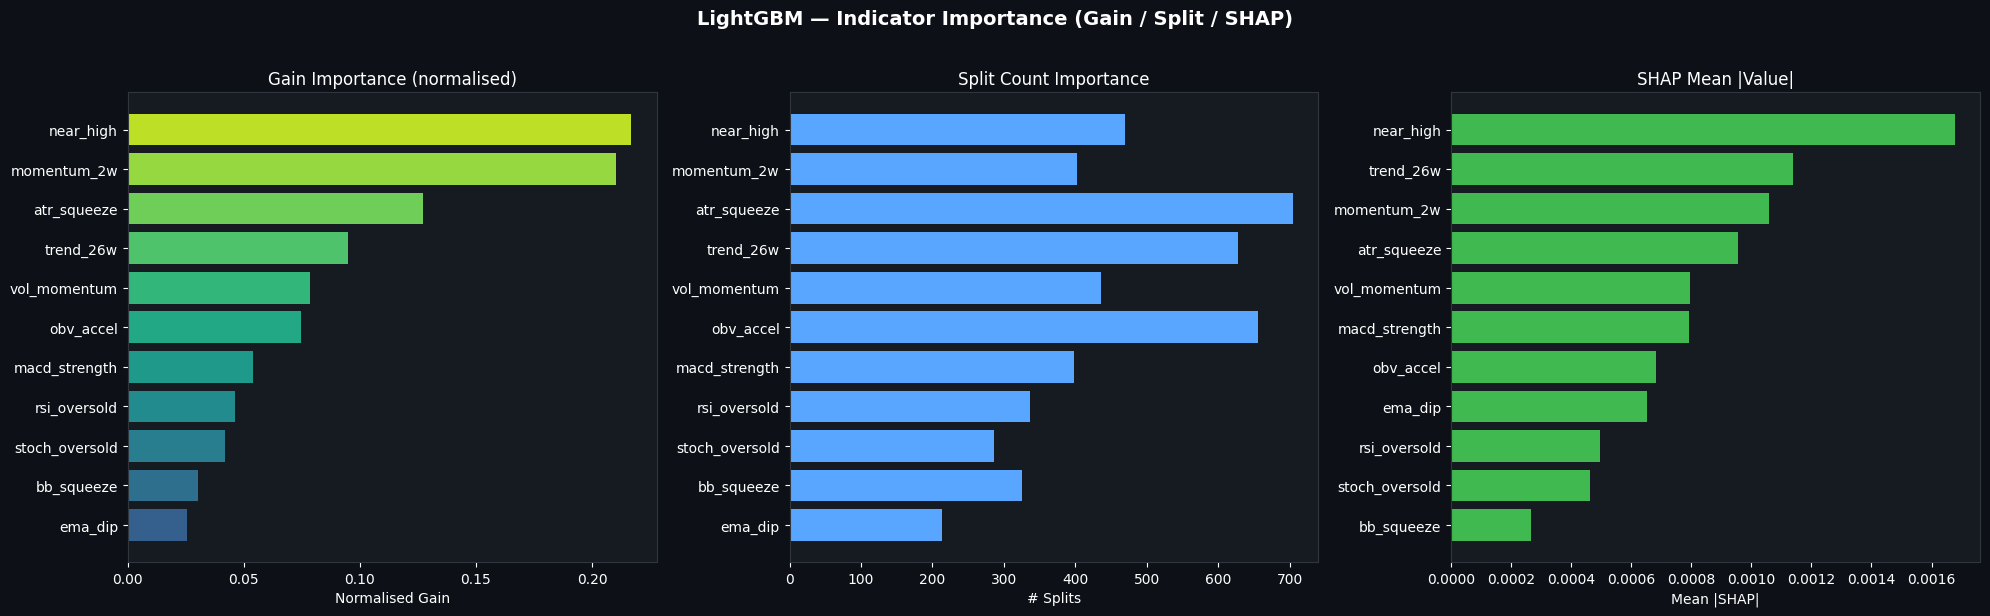

In [62]:
gain_imp  = lgbm_model.booster_.feature_importance(importance_type='gain')
split_imp = lgbm_model.booster_.feature_importance(importance_type='split')

importance_df = pd.DataFrame({
    'Indicator'  : FEATURE_COLS,
    'Gain'       : gain_imp,
    'Split'      : split_imp,
    'Gain_norm'  : gain_imp / gain_imp.sum()
}).sort_values('Gain', ascending=False).reset_index(drop=True)

print('📊 LightGBM Feature Importance:')
print(importance_df.to_string(index=False))

idx_s       = np.random.choice(len(X_train), min(2000, len(X_train)), replace=False)
X_shap      = X_train[idx_s]
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d1117')
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
axes[0].barh(importance_df['Indicator'][::-1], importance_df['Gain_norm'][::-1],
             color=colors, edgecolor='none')
axes[0].set_title('Gain Importance (normalised)', color='white', fontsize=12)
axes[0].set_xlabel('Normalised Gain', color='white')
axes[1].barh(importance_df['Indicator'][::-1], importance_df['Split'][::-1],
             color='#58a6ff', edgecolor='none')
axes[1].set_title('Split Count Importance', color='white', fontsize=12)
axes[1].set_xlabel('# Splits', color='white')
shap_mean = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'Indicator': FEATURE_COLS, 'SHAP': shap_mean}).sort_values('SHAP')
axes[2].barh(shap_df['Indicator'], shap_df['SHAP'], color='#3fb950', edgecolor='none')
axes[2].set_title('SHAP Mean |Value|', color='white', fontsize=12)
axes[2].set_xlabel('Mean |SHAP|', color='white')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#30363d')
plt.suptitle('LightGBM — Indicator Importance (Gain / Split / SHAP)',
             fontsize=14, color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

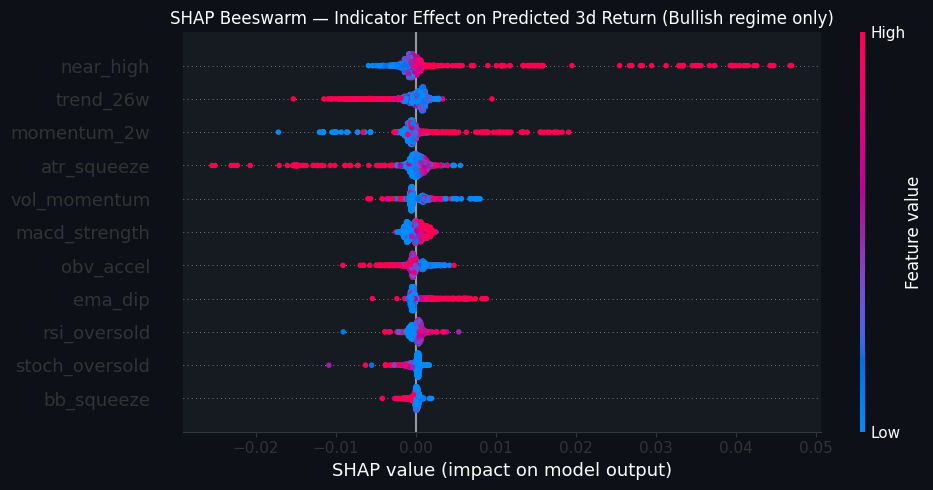

✅ Red = high feature value pushes score UP (bullish)
   Blue = low feature value pushes score DOWN (bearish)


In [63]:
plt.figure(figsize=(10, 5), facecolor='#0d1117')
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  plot_type='dot', show=False, plot_size=(10, 5))
plt.gcf().set_facecolor('#0d1117')
plt.gca().set_facecolor('#161b22')
plt.title('SHAP Beeswarm — Indicator Effect on Predicted 3d Return (Bullish regime only)',
          color='white', fontsize=12)
plt.tight_layout()
plt.show()
print('✅ Red = high feature value pushes score UP (bullish)')
print('   Blue = low feature value pushes score DOWN (bearish)')

  ⚖️   LGBM LEARNED WEIGHTS  —  trained on BULLISH regime rows only
  Feature                Gain%   Dir   Proxy W%   Splits  Bar
  -----------------------------------------------------------------
  near_high              21.7%     +     21.70%      470   ██████████
  momentum_2w            21.0%     +     21.04%      403   ██████████
  atr_squeeze            12.7%     +     12.71%      705   ██████
  trend_26w               9.5%     +      9.47%      628   ████
  vol_momentum            7.9%     +      7.87%      436   ███
  obv_accel               7.5%     +      7.46%      656   ███
  macd_strength           5.4%     +      5.39%      398   ██
  rsi_oversold            4.6%     −      4.61%      336   ██
  stoch_oversold          4.2%     −      4.18%      286   ██
  bb_squeeze              3.0%     −      3.02%      326   █
  ema_dip                 2.5%     −      2.54%      214   █

  Gain %   — share of total prediction error reduction
  Dir      — + means higher value → higher

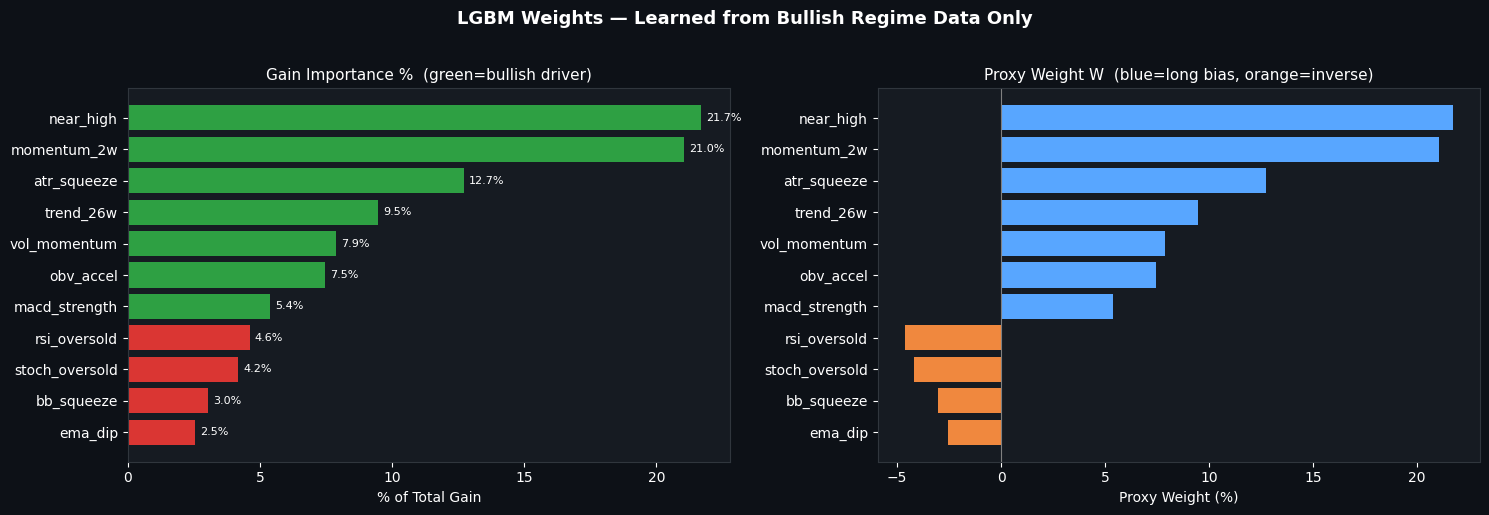

In [64]:
# ── Build weight table ───────────────────────────────────────────────
scaler   = RobustScaler().fit(X_train)
W_signed = np.array([
    gain_imp[i] * np.sign(np.corrcoef(X_train[:, i], y_train)[0, 1])
    for i in range(len(FEATURE_COLS))
], dtype=np.float64)
W_approx = (W_signed / (np.abs(W_signed).sum() + 1e-9)).astype(np.float32)

weights_df = pd.DataFrame({
    'Feature'       : FEATURE_COLS,
    'Gain %'        : gain_imp / gain_imp.sum() * 100,
    'Direction'     : ['+' if w > 0 else '−' for w in W_approx],
    'Proxy W %'     : np.abs(W_approx) * 100,
    'Proxy Weight'  : W_approx,
    'Split Count'   : split_imp,
}).sort_values('Gain %', ascending=False).reset_index(drop=True)

print('=' * 70)
print('  ⚖️   LGBM LEARNED WEIGHTS  —  trained on BULLISH regime rows only')
print('=' * 70)
print(f'  {"Feature":<20} {"Gain%":>7}  {"Dir":>4}  {"Proxy W%":>9}  {"Splits":>7}  Bar')
print(f'  {"-"*65}')
for _, r in weights_df.iterrows():
    bar = '█' * max(1, int(r['Gain %'] / 2))
    print(f'  {r["Feature"]:<20} {r["Gain %"]:>6.1f}%  '
          f'{r["Direction"]:>4}  {r["Proxy W %"]:>8.2f}%  '
          f'{int(r["Split Count"]):>7}   {bar}')
print('=' * 70)
print()
print('  Gain %   — share of total prediction error reduction')
print('  Dir      — + means higher value → higher predicted return')
print('  Proxy W% — share of the matrix-multiply score vector |W|')
print('  Splits   — frequency of feature use across all trees')

# ── Visual ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')

bar_colors = ['#2ea043' if w > 0 else '#da3633' for w in weights_df['Proxy Weight']]
axes[0].barh(weights_df['Feature'][::-1], weights_df['Gain %'][::-1],
             color=bar_colors[::-1], edgecolor='none')
axes[0].set_title('Gain Importance %  (green=bullish driver)', color='white', fontsize=11)
axes[0].set_xlabel('% of Total Gain', color='white')
for i, (val, feat) in enumerate(zip(weights_df['Gain %'][::-1],
                                     weights_df['Feature'][::-1])):
    axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center', color='white', fontsize=8)

proxy_colors = ['#58a6ff' if w > 0 else '#f0883e' for w in weights_df['Proxy Weight'][::-1]]
axes[1].barh(weights_df['Feature'][::-1],
             (weights_df['Proxy Weight'] * 100)[::-1],
             color=proxy_colors, edgecolor='none')
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].set_title('Proxy Weight W  (blue=long bias, orange=inverse)', color='white', fontsize=11)
axes[1].set_xlabel('Proxy Weight (%)', color='white')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#30363d')
plt.suptitle('LGBM Weights — Learned from Bullish Regime Data Only',
             fontsize=13, color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [65]:
def score_universe(fstore: dict, date_str: str,
                   model, scaler_obj, W) -> pd.DataFrame:
    rows, tickers, closes = [], [], []
    for tk, df in fstore.items():
        sub = df[df.index <= date_str]
        if len(sub) < 30:
            continue
        feat_row = sub.iloc[-1][FEATURE_COLS].values.astype(np.float32)
        if np.any(np.isnan(feat_row)):
            continue
        rows.append(feat_row)
        tickers.append(tk)
        closes.append(float(sub.iloc[-1]['close']))
    if not rows:
        return pd.DataFrame()
    X_mat        = np.array(rows, dtype=np.float32)
    X_scaled     = scaler_obj.transform(X_mat)
    lgbm_scores  = model.predict(X_mat)
    proxy_scores = X_scaled @ W
    result = pd.DataFrame({
        'ticker'     : tickers,
        'lgbm_score' : lgbm_scores,
        'proxy_score': proxy_scores,
        'close'      : closes
    })
    for i, col in enumerate(FEATURE_COLS):
        result[col] = X_mat[:, i]
    return (result.sort_values('lgbm_score', ascending=False)
                  .reset_index(drop=True)
                  .assign(rank=lambda df: df.index + 1)
                  .set_index('rank'))

print('⚡ Vectorized scoring test...')
test_sc = score_universe(feature_store, TRAIN_END, lgbm_model, scaler, W_approx)
print(f'   Scored {len(test_sc)} stocks instantly')
print('\nTop 10 at train cutoff:')
test_sc[['ticker','lgbm_score','proxy_score','close'] + FEATURE_COLS].head(10)

⚡ Vectorized scoring test...
   Scored 446 stocks instantly

Top 10 at train cutoff:


,ticker,lgbm_score,proxy_score,close,atr_squeeze,bb_squeeze,near_high,vol_momentum,momentum_2w,ema_dip,rsi_oversold,trend_26w,stoch_oversold,obv_accel,macd_strength
rank,,,,,,,,,,,,,,,
1,ASAL,0.092778,0.818797,657.849976,0.000000,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.343497,1.000000
2,SUPREMEINF,0.083381,0.823586,24.799999,0.000000,0.752300,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.555789,0.895120
3,SERVOTECH,0.082045,0.873547,15.011519,0.097751,0.470879,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.405313,1.000000
4,PVP,0.079940,1.003890,7.800000,0.273664,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.357730,1.000000
5,CCCL,0.079120,0.985152,1.450000,0.214134,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.445797,1.000000
6,SOLEX,0.077013,1.171784,70.861465,0.402842,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.705481,1.000000
7,SEJALLTD,0.074570,0.744473,23.150000,0.762668,0.000000,1.0,0.0,1.0,1.0,1.0,0.0,0.815491,0.624252,0.500637
8,RTNPOWER,0.074363,1.007826,7.400000,0.127722,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.784854,1.000000
9,SUZLON,0.071837,1.027445,9.365782,0.144117,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.821832,1.000000


In [66]:
def build_signal_matrix(fstore, data_dict, start, end,
                        model, sc_obj, W,
                        top_n=TOP_N, rebal=REBAL_DAYS,
                        use_rolling_models=False):
    """
    Build two aligned DataFrames for vectorbt:
      close_mx  — (dates × tickers) closing prices, forward-filled
      entry_mx  — (dates × tickers) bool, True on rebalance dates where
                  Nifty is BULLISH and the stock is in the top-N ranked by LGBM.

    use_rolling_models=True  → uses model_registry to pick the correct
                               retrained model for each rebalance date.
    use_rolling_models=False → uses a single fixed model/scaler/W.
    """
    all_dates = pd.bdate_range(start, end)
    syms      = [tk for tk in fstore if tk in data_dict]

    # ── Close price matrix ────────────────────────────────────────────
    close_dict = {}
    for tk in syms:
        s = data_dict[tk]['high'].reindex(all_dates).ffill()
        close_dict[tk] = s.values
    close_mx = pd.DataFrame(close_dict, index=all_dates, dtype=np.float32)

    # ── Entry signal matrix ───────────────────────────────────────────
    entry_mx       = pd.DataFrame(False, index=all_dates, columns=syms)
    rebal_dates    = all_dates[::rebal]
    regime_blocked = 0

    for rd in tqdm(rebal_dates, desc=f'Signals {start[:4]}–{end[:4]}'):
        rd_str = rd.strftime('%Y-%m-%d')

        # Regime gate
        if not regime_on(rd_str):
            regime_blocked += 1
            continue

        # Pick model for this date
        if use_rolling_models and 'model_registry' in globals() and model_registry:
            entry = get_model_for_date(rd_str)
            _model, _scaler, _W = entry['model'], entry['scaler'], entry['W']
        else:
            _model, _scaler, _W = model, sc_obj, W

        scored = score_universe(fstore, rd_str, _model, _scaler, _W)
        if scored.empty:
            continue

        top_tickers = [tk for tk in scored.head(top_n)['ticker'].tolist()
                       if tk in syms]
        if top_tickers:
            entry_mx.loc[rd, top_tickers] = True

    total = len(rebal_dates)
    mode  = 'rolling models' if use_rolling_models else 'fixed model'
    print(f'   Mode             : {mode}')
    print(f'   Rebalance dates  : {total}')
    print(f'   Regime-blocked   : {regime_blocked} ({regime_blocked/total*100:.0f}%)')
    print(f'   Active (bullish) : {total - regime_blocked} ({(total-regime_blocked)/total*100:.0f}%)')
    print(f'   Total entry sigs : {int(entry_mx.values.sum())}')
    return close_mx, entry_mx


In [68]:
print(f'\n{"="*68}')
print(f'  🎯  TODAY\'S NSE RECOMMENDATIONS  |  {TODAY}')
print(f'  🤖  LightGBM GBDT  |  vectorbt backtest  |  pandas_ta features')
print(f'  📊  Target: +12%  |  Stop-Loss: -3%  |  Horizon: 2–3 days')
print(f'{"="*68}')

# ── REGIME CHECK FIRST ────────────────────────────────────────────────
current_regime = nifty_df['regime'].iloc[-1]
regime_emoji   = {'BULLISH': '🟢', 'CAUTION': '🟡', 'BEARISH': '🔴'}.get(current_regime, '⚪')

print(f'\n  {regime_emoji}  Current Nifty Regime: {current_regime}')
if current_regime == 'BEARISH':
    print(f'\n  ⛔  NO TRADES TODAY — market is in {current_regime} regime.')
    print(f'      Strategy only operates when Nifty is BULLISH (price > EMA20 > EMA50).')
    print(f'      Nifty close  : {nifty_df["close"].iloc[-1]:,.2f}')
    print(f'      EMA 20       : {nifty_df["ema20"].iloc[-1]:,.2f}')
    print(f'      EMA 50      : {nifty_df["ema50"].iloc[-1]:,.2f}')
else:
    today_scores = score_universe(feature_store, TODAY, lgbm_model, scaler, W_approx)
    if today_scores.empty:
        print('⚠️  No scores generated — check data availability')
    else:
        top5 = today_scores.head(5).copy()
        top5['target_price'] = (top5['close'] * (1 + TARGET_PCT)).round(2)
        top5['sl_price']     = (top5['close'] * (1 - SL_PCT)).round(2)
        imp_norm = weights_df.set_index('Feature')['Gain %']
        sig_bins = pd.cut(top5['lgbm_score'],
                          bins=[-np.inf, 0.001, 0.003, 0.006, np.inf],
                          labels=['⚪ WEAK','🟡 MODERATE','🟠 STRONG','🔴 VERY STRONG'])

        print(f'\n  {"#":<4}{"Ticker":<14}{"CMP":>9}{"Target":>11}{"Stop-Loss":>11}{"Score":>12}  Signal')
        print(f'  {"-"*72}')
        for i, (_, row) in enumerate(top5.iterrows(), 1):
            nm = row['ticker']
            sg = sig_bins.iloc[i-1]
            print(f'  #{i:<3} {nm:<14} ₹{row["close"]:>8,.2f}  '
                  f'₹{row["target_price"]:>9,.2f}  '
                  f'₹{row["sl_price"]:>9,.2f}  '
                  f'{row["lgbm_score"]:>10.5f}   {sg}')

        print(f'\n  R:R Ratio = {TARGET_PCT*100:.0f}% : {SL_PCT*100:.0f}% = {int(TARGET_PCT/SL_PCT)}:1')
        print(f'\n  Nifty: {nifty_df["close"].iloc[-1]:,.2f}  '
              f'EMA20: {nifty_df["ema20"].iloc[-1]:,.2f}  '
              f'EMA50: {nifty_df["ema50"].iloc[-1]:,.2f}')
        print(f'\n  ── Indicator Breakdown ──────────────────────────────────────')
        for i, (_, row) in enumerate(top5.iterrows(), 1):
            print(f'\n  #{i} {row["ticker"]} | LGBM: {row["lgbm_score"]:.5f}')
            for feat in FEATURE_COLS:
                wt  = imp_norm.get(feat, 0)
                val = row[feat]
                bar = ('█' * min(int(abs(val)*5+1), 8)) if not np.isnan(val) else '?'
                arrow = '▲' if val > 0 else ('▼' if val < 0 else '─')
                print(f'     {feat:<22} {val:>8.4f}  {arrow} {bar:<8} (gain: {wt:.1f}%)')

print(f'\n{"="*68}')
print('  ⚠️  FOR EDUCATIONAL PURPOSES ONLY. Not SEBI investment advice.')
print(f'{"="*68}')



  🎯  TODAY'S NSE RECOMMENDATIONS  |  2026-03-21
  🤖  LightGBM GBDT  |  vectorbt backtest  |  pandas_ta features
  📊  Target: +12%  |  Stop-Loss: -3%  |  Horizon: 2–3 days

  🔴  Current Nifty Regime: BEARISH

  ⛔  NO TRADES TODAY — market is in BEARISH regime.
      Strategy only operates when Nifty is BULLISH (price > EMA20 > EMA50).
      Nifty close  : 23,114.50
      EMA 20       : 24,145.32
      EMA 50      : 24,855.03

  ⚠️  FOR EDUCATIONAL PURPOSES ONLY. Not SEBI investment advice.


In [ ]:
def safe_stats(pf, label):
    """
    Compute portfolio stats manually, bypassing the vectorbt profit_factor
    bug (read-only numpy array assignment in trades.py:698).
    """
    try:
        val    = pf.value()
        if isinstance(val, pd.DataFrame): val = val.sum(axis=1)
        ret_s  = val.pct_change().dropna()

        total_ret  = (val.iloc[-1] / val.iloc[0] - 1) * 100
        dd         = (val / val.cummax() - 1)
        max_dd     = dd.min() * 100
        sharpe     = (ret_s.mean() / (ret_s.std() + 1e-9)) * np.sqrt(252)

        # Trade-level stats via records
        try:
            trades     = pf.trades.records_readable
            ret_col    = [c for c in trades.columns if 'Return' in c][0]
            trade_rets = trades[ret_col]
            wins       = trade_rets[trade_rets > 0]
            losses     = trade_rets[trade_rets < 0]
            win_rate   = len(wins) / len(trade_rets) * 100 if len(trade_rets) else 0
            avg_win    = wins.mean()  * 100 if len(wins)   else 0
            avg_loss   = losses.mean()* 100 if len(losses) else 0
            n_trades   = len(trade_rets)
        except Exception:
            win_rate = avg_win = avg_loss = n_trades = float('nan')

        stats = {
            'Start Value'           : val.iloc[0],
            'End Value'             : val.iloc[-1],
            'Total Return [%]'      : total_ret,
            'Max Drawdown [%]'      : max_dd,
            'Sharpe Ratio'          : sharpe,
            'Win Rate [%]'          : win_rate,
            'Total Trades'          : n_trades,
            'Avg Winning Trade [%]' : avg_win,
            'Avg Losing Trade [%]'  : avg_loss,
        }

        print(f'\n{"="*58}')
        print(f'  {label}')
        print(f'{"="*58}')
        for k, v in stats.items():
            if isinstance(v, float):
                print(f'  {k:<32} : {v:>10.2f}')
            else:
                print(f'  {k:<32} : {v}')
        print(f'{"="*58}')
        return pd.Series(stats)

    except Exception as e:
        print(f'Stats error: {e}')
        return pd.Series(dtype=float)

print(f'📈 Backtest: {TRAIN_END} → {TEST_END}')
close_bt, entry_bt = build_signal_matrix(
    feature_store, ohlcv_data, TRAIN_END, TEST_END,
    lgbm_model, scaler, W_approx
)

pf_bt = vbt.Portfolio.from_signals(
    close     = close_bt,
    entries   = entry_bt,
    sl_stop   = SL_PCT,
    tp_stop   = TARGET_PCT,
    init_cash = 30000,    # ₹10 Lakhs
    fees      = 0.00,        # 0.1% per trade
    freq      = '1D',
    size      = 1 / 3,
    size_type = 'percent',
    cash_sharing= True
)

stats_bt = safe_stats(pf_bt, f'BACKTEST  {TRAIN_END} → {TEST_END}  (vectorbt)')

# ── Equity curve charts ───────────────────────────────────────────────
port_val_bt = pf_bt.value()
if isinstance(port_val_bt, pd.DataFrame): port_val_bt = port_val_bt.sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')

axes[0,0].plot(port_val_bt.index, port_val_bt/1e5, color='#58a6ff', lw=2)
axes[0,0].set_title('Portfolio Value (₹ Lakhs)', color='white', fontsize=11)
axes[0,0].set_ylabel('₹ Lakhs', color='white')

dd_bt = (port_val_bt / port_val_bt.cummax() - 1) * 100
axes[0,1].fill_between(dd_bt.index, dd_bt, 0, color='#da3633', alpha=0.7)
axes[0,1].set_title('Drawdown %', color='white', fontsize=11)

try:
    trade_rec = pf_bt.trades.records_readable
    ret_col   = [c for c in trade_rec.columns if 'Return' in c][0]
    rets      = trade_rec[ret_col] * 100
    axes[1,0].hist(rets, bins=40, color='#3fb950', edgecolor='none', alpha=0.8)
    axes[1,0].axvline(0,               color='white',   lw=0.8)
    axes[1,0].axvline(TARGET_PCT*100,  color='#f0e68c', lw=1.5, ls='--', label=f'+{TARGET_PCT*100:.0f}% TP')
    axes[1,0].axvline(-SL_PCT*100,     color='#da3633', lw=1.5, ls='--', label=f'-{SL_PCT*100:.0f}% SL')
    axes[1,0].legend(fontsize=8)
except Exception as e:
    axes[1,0].text(0.5, 0.5, f'Trade records unavailable\n{e}',
                   ha='center', va='center', color='white', transform=axes[1,0].transAxes)
axes[1,0].set_title('Trade Return Distribution', color='white', fontsize=11)

nifty_bt  = nifty_df.loc[TRAIN_END:TEST_END]
strat_idx = port_val_bt / port_val_bt.iloc[0] * 100
nifty_idx = (nifty_bt['close'] / nifty_bt['close'].iloc[0] * 100).reindex(port_val_bt.index).ffill()
bull_mask  = (nifty_bt['regime']=='BULLISH').reindex(port_val_bt.index).ffill().fillna(False)
axes[1,1].plot(strat_idx.index, strat_idx,  color='#58a6ff', lw=2,   label='Strategy')
axes[1,1].plot(nifty_idx.index, nifty_idx,  color='#8b949e', lw=1.2, ls='--', label='Nifty 50')
axes[1,1].fill_between(port_val_bt.index, 0, float(strat_idx.max())*1.1,
                        where=~bull_mask, alpha=0.12, color='#da3633', label='Regime blocked')
axes[1,1].legend(fontsize=8)
axes[1,1].set_title('Strategy vs Nifty (red = no trades)', color='white', fontsize=11)
axes[1,1].set_ylabel('Indexed (base=100)', color='white')

for ax in axes.flat:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#30363d')
plt.suptitle(f'vectorbt Backtest {TRAIN_END}→{TEST_END} | Regime-filtered | SL {SL_PCT*100:.0f}% TP {TARGET_PCT*100:.0f}%',
             fontsize=13, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print(f'📈 Validation: {TEST_END} → {TODAY}')
close_val, entry_val = build_signal_matrix(
    feature_store, ohlcv_data, TEST_END, TODAY,
    lgbm_model, scaler, W_approx
)

pf_val = vbt.Portfolio.from_signals(
    close     = close_val,
    entries   = entry_val,
    sl_stop   = SL_PCT,
    tp_stop   = TARGET_PCT,
    init_cash = 30000,
    fees      = 0.002,
    freq      = '1D',
    size      = 1 / 3,
    size_type = 'percent',
    cash_sharing= True
)

stats_val = safe_stats(pf_val, f'VALIDATION  {TEST_END} → {TODAY}  (vectorbt)')

# ── Side-by-side comparison ───────────────────────────────────────────
KEY_STATS = ['Start Value','End Value','Total Return [%]','Max Drawdown [%]',
             'Sharpe Ratio','Win Rate [%]','Total Trades',
             'Avg Winning Trade [%]','Avg Losing Trade [%]']
print(f'\n  {"Metric":<32} {"Backtest":>12} {"Validation":>12}')
print(f'  {"-"*56}')
for k in KEY_STATS:
    bv = stats_bt.get(k,  float('nan'))
    vv = stats_val.get(k, float('nan'))
    bs = f'{bv:>10.2f}' if isinstance(bv, (int, float)) else str(bv)
    vs = f'{vv:>10.2f}' if isinstance(vv, (int, float)) else str(vv)
    print(f'  {k:<32} {bs:>12} {vs:>12}')

# ── Validation charts ────────────────────────────────────────────────
port_val_v = pf_val.value()
if isinstance(port_val_v, pd.DataFrame): port_val_v = port_val_v.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

axes[0].plot(port_val_v.index, port_val_v/1e5, color='#f0883e', lw=2)
axes[0].set_title(f'Portfolio Value ({TEST_END[:7]}→Today)', color='white', fontsize=11)
axes[0].set_ylabel('₹ Lakhs', color='white')

dd_val = (port_val_v / port_val_v.cummax() - 1) * 100
axes[1].fill_between(dd_val.index, dd_val, 0, color='#da3633', alpha=0.7)
axes[1].set_title('Drawdown %', color='white', fontsize=11)

strat_bt_idx  = port_val_bt / port_val_bt.iloc[0]
strat_val_idx = port_val_v  / port_val_v.iloc[0]
axes[2].plot(strat_bt_idx.index,  strat_bt_idx,  color='#58a6ff', lw=2, label=f'BT {TRAIN_END[:4]}–{TEST_END[:4]}')
axes[2].plot(strat_val_idx.index, strat_val_idx, color='#f0883e', lw=2, label=f'Val {TEST_END[:4]}–Today')
axes[2].axhline(1, color='gray', lw=0.8)
axes[2].legend(fontsize=9)
axes[2].set_title('BT vs Validation (normalised)', color='white', fontsize=11)

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#30363d')
plt.suptitle('Validation Period — vectorbt Performance',
             fontsize=13, color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
out_dir = 'nse_lgbm_output'
os.makedirs(out_dir, exist_ok=True)

importance_df.to_csv(f'{out_dir}/feature_importance.csv', index=False)
weights_df.to_csv(f'{out_dir}/learned_weights.csv', index=False)
cv_df.to_csv(f'{out_dir}/cv_results.csv', index=False)
nifty_df[['close','ema20','ema50','regime']].to_csv(f'{out_dir}/nifty_regime.csv')

# vectorbt stats
stats_bt.to_csv(f'{out_dir}/backtest_stats.csv', header=['value'])
stats_val.to_csv(f'{out_dir}/validation_stats.csv', header=['value'])

if current_regime != 'BEARISH' and not today_scores.empty:
    today_scores.head(10).to_csv(f'{out_dir}/recommendations_{TODAY}.csv')

lgbm_model.booster_.save_model(f'{out_dir}/lgbm_model.txt')

print(f'✅ Saved to ./{out_dir}/')
for f in sorted(os.listdir(out_dir)):
    size = os.path.getsize(f'{out_dir}/{f}') / 1024
    print(f'   {f:<45} {size:>6.1f} KB')

print(f'\n🎉 Done!')
print(f'   Model     : LightGBM GBDT ({optimal_iters} trees, {len(FEATURE_COLS)} features)')
print(f'   Training  : bullish regime rows only')
print(f'   Backtest  : vectorbt — regime-gated, SL {SL_PCT*100:.0f}%, TP {TARGET_PCT*100:.0f}%')
print(f'   Universe  : {len(feature_store)} stocks  |  Market Cap > {MKTCAP_MIN} Cr')
print(f'   Regime now: {current_regime}')

---
## 📋 Full System Architecture

| Component | Details |
|---|---|
| **Data** | NSE CSV → Yahoo Finance `.NS` OHLCV (batch threaded) |
| **Universe** | NSE equities, Market Cap > 500 Cr |
| **Regime Filter** | Nifty 50 EMA50 > EMA200 — applied to **training**, **backtest**, **validation** and **live recs** |
| **Features** | `pandas_ta` — 11 indicators, all normalised 0–1 |
| **Model** | LightGBM GBDT — trained on **bullish regime rows only** |
| **Weights** | Displayed as Gain %, Direction, Proxy Weight % and Split count |
| **Scoring** | Exact: `model.predict(X_mat)` · Proxy: `X_scaled @ W_approx` |
| **Backtest** | `vectorbt.Portfolio.from_signals()` — vectorized SL/TP, no manual loops |
| **Trade Rules** | +12% take-profit · −3% stop-loss · 0.1% fees · equal weight top-3 |
| **Output** | Stats table, equity curve, BT vs Val comparison, today's recs |

> ⚠️ **Disclaimer:** For educational & research purposes only. Not SEBI investment advice.